# Event-aligned portfolio impacts

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/RiskThinking/crc-docs/blob/main/notebooks/portfolio_impact.ipynb) · [GitHub preview](https://github.com/RiskThinking/crc-docs/blob/main/notebooks/portfolio_impact.ipynb)

Return-period flood depth is an exposure. An *impact function* maps that exposure
onto a decision quantity — here a hypothetical fractional damage ratio — while
preserving the same event alignment (the 100-year depth becomes the 100-year
damage ratio, not a re-ranked quantile).

1. **Raw evaluation** — depth at each return period (same API as the portfolio notebook).
2. **Impact evaluation** — `PiecewiseLinearImpact` from `crc_sdk.impacts` (backed by `crc_framework`).
3. **Dollar loss** — damage ratio × replacement value, compared before/after.

Builds on the same Cologne assets and canonical hazard file.


**Workflow:** [AI skill](https://github.com/RiskThinking/crc-docs/blob/main/.agents/skills/crc-model-flood-insurance-loss/SKILL.md) · [Python pipeline](https://github.com/RiskThinking/crc-docs/blob/main/pipelines/portfolio_impact_pipeline.py) · [Setup and tested versions](https://github.com/RiskThinking/crc-docs/blob/main/ai-playbooks/docs/setup.md) · [All problems](https://github.com/RiskThinking/crc-docs/blob/main/README.md#choose-a-problem)


## Run the notebook

In Colab, choose **Runtime → Run all**. The setup cell installs the required
packages and downloads any small repository files used by the analysis.


In [1]:
#@title Install dependencies and prepare this notebook
import hashlib
import importlib
import importlib.metadata
import importlib.util
import os
from pathlib import Path
import subprocess
import sys
import sysconfig
import urllib.request

if sys.version_info < (3, 12):
    raise RuntimeError("Use a Python 3.12+ runtime (Colab: Runtime > Change runtime type).")

# Install into this kernel's Python, not a separate shell environment.
REQUIREMENTS = ['crc-sdk[geometry]==0.7.1', 'crc-framework==0.2.5', 'duckdb>=1.4.5,<2', 'numpy>=1.26,<3', 'pandas>=2.2,<4', 'plotly==6.9.0', 'nbformat>=5.10,<6']
loaded_versions = {
    module: getattr(sys.modules[module], "__version__", None)
    for module in ("numpy", "pandas", "pyarrow", "plotly", "duckdb", "crc_sdk", "crc_framework")
    if module in sys.modules
}
if importlib.util.find_spec("pip") is None:
    subprocess.check_call([sys.executable, "-m", "ensurepip", "--upgrade"])
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "--quiet", "--disable-pip-version-check",
    *REQUIREMENTS,
])
importlib.invalidate_caches()
for module, loaded in loaded_versions.items():
    installed = importlib.metadata.version(module.replace("_", "-"))
    if loaded is not None and loaded != installed:
        raise RuntimeError("Packages changed after import. Restart the kernel/session, then run all cells again.")
os.environ["PATH"] = sysconfig.get_path("scripts") + os.pathsep + os.environ.get("PATH", "")
IN_COLAB = importlib.util.find_spec("google.colab") is not None if importlib.util.find_spec("google") else False

# A local checkout keeps its files; standalone/Colab runs download only required resources.
RESOURCE_REVISION = '52ff7a93028cc1e64f3b1df856851650df825dc8'
RESOURCE_SHA256 = {'fixtures/os_climate/hazard.parquet': '60550f032692da9a824ff3a832dd142d4732717ff2a7e6084781d803c73a6c96', 'fixtures/os_climate/assets.parquet': '1150ddb98d339e79bd3f647f109c523a498edac8393d71bc9f9d4b2aec37f5d8'}
REPO_ROOT = next((
    folder for folder in (Path.cwd(), *Path.cwd().parents)
    if (folder / "pyproject.toml").is_file()
    and 'name = "crc-docs"' in (folder / "pyproject.toml").read_text()
), None)
if REPO_ROOT is None:
    REPO_ROOT = next((
        folder for folder in (Path.cwd(), *Path.cwd().parents)
        if (folder / ".crc-notebook-revision").is_file()
        and (folder / ".crc-notebook-revision").read_text() == RESOURCE_REVISION
    ), Path.cwd() / ".crc-docs" / RESOURCE_REVISION)
    REPO_ROOT.mkdir(parents=True, exist_ok=True)
    (REPO_ROOT / ".crc-notebook-revision").write_text(RESOURCE_REVISION)
    for relative, expected_hash in RESOURCE_SHA256.items():
        target = REPO_ROOT / relative
        if not target.exists() or hashlib.sha256(target.read_bytes()).hexdigest() != expected_hash:
            url = f"https://raw.githubusercontent.com/RiskThinking/crc-docs/{RESOURCE_REVISION}/{relative}"
            with urllib.request.urlopen(url, timeout=120) as response:
                content = response.read()
            if hashlib.sha256(content).hexdigest() != expected_hash:
                raise RuntimeError(f"Resource checksum mismatch: {relative}")
            target.parent.mkdir(parents=True, exist_ok=True)
            target.write_bytes(content)
NOTEBOOK_DIR = REPO_ROOT / "notebooks"
NOTEBOOK_DIR.mkdir(parents=True, exist_ok=True)
os.chdir(NOTEBOOK_DIR)

print(f"Ready: Python {sys.version.split()[0]}, crc-sdk {importlib.metadata.version('crc-sdk')}")
print(f"Working directory: {NOTEBOOK_DIR}")


Ready: Python 3.12.10, crc-sdk 0.7.1
Working directory: /Users/woozyking/rtai/crc-docs/notebooks


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
import pyarrow.parquet as pq

from crc_sdk.connectors import read_hazard_dataset
from crc_sdk.impacts import PiecewiseLinearImpact
from crc_sdk.workflows import ExecutionOptions, HazardDataset

# Use the native interactive renderer; maintainers can opt into saved PNG previews.
STATIC_PREVIEW = os.environ.get("CRC_NOTEBOOK_STATIC_PREVIEW") == "1"
pio.renderers.default = (
    "colab" if IN_COLAB else "plotly_mimetype+png" if STATIC_PREVIEW else "plotly_mimetype"
)

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
FIXTURE_DIR = Path("../fixtures/os_climate")

HAZARD_NAME = "RiverineInundation"
PATHWAY = "historical"
HORIZON = 1980
RETURN_PERIODS = [25, 50, 100, 250, 500, 1000]

HAZARD_PATH = FIXTURE_DIR / "hazard.parquet"
ASSETS_PATH = FIXTURE_DIR / "assets.parquet"
RAW_PATH = DATA_DIR / "cologne_portfolio_before_impact.parquet"
IMPACT_PATH = DATA_DIR / "cologne_portfolio_after_impact.parquet"

DEPTH_DAMAGE = PiecewiseLinearImpact(
    exposure=[0.0, 0.1, 0.5, 1.0, 2.0, 4.0],
    impact=[0.0, 0.01, 0.08, 0.22, 0.55, 1.0],
)


## 1. Assets and hazard

Load the same checked-in Cologne assets and canonical hazard fixture used by the
portfolio notebook. No remote data access is required.


In [3]:
assets = pq.read_table(ASSETS_PATH)
hazard = read_hazard_dataset(HAZARD_PATH)
print(f"assets: {assets.num_rows} <- {ASSETS_PATH}")
print(f"hazard: {hazard.num_rows} rows <- {HAZARD_PATH}")
assets.to_pandas()


assets: 3 <- ../fixtures/os_climate/assets.parquet
hazard: 11 rows <- ../fixtures/os_climate/hazard.parquet


,asset_id,longitude,latitude,sector,replacement_value
0,warehouse-a,6.96030,50.93750,logistics,12000000
1,warehouse-b,6.96031,50.93751,logistics,8500000
2,warehouse-c,6.96029,50.93749,manufacturing,21000000


## 2. Before / after impact

`.impact(...)` accepts any `ImpactFunction` — including framework builtins like
`PiecewiseLinearImpact` / `SigmoidImpact`, or a plain vectorized callable wrapped
as `CallableImpact`. The output keeps the same RP column names; only the value
semantics and units change (recorded in Parquet metadata as `event_aligned`).


In [4]:
request = (
    HazardDataset.local(HAZARD_PATH)
    .for_assets(ASSETS_PATH)
    .select(
        hazard_names=[HAZARD_NAME],
        horizons=[HORIZON],
        pathways=[PATHWAY],
    )
    .return_periods(RETURN_PERIODS)
)
execution = ExecutionOptions(max_workers=1)
raw_result = request.write_parquet(RAW_PATH, execution=execution)
impact_result = request.impact(
    DEPTH_DAMAGE,
    name="piecewise_depth_damage",
    value_unit="fraction",
    value_semantics="hypothetical fractional asset damage",
).write_parquet(IMPACT_PATH, execution=execution)

raw = pq.read_table(RAW_PATH).to_pandas().set_index("asset_id")
impacted = pq.read_table(IMPACT_PATH).to_pandas().set_index("asset_id")
assert list(raw_result.value_columns) == list(impact_result.value_columns)

rows = []
for asset_id, raw_row in raw.iterrows():
    impact_row = impacted.loc[asset_id]
    replacement = float(raw_row["replacement_value"])
    for period, column in zip(RETURN_PERIODS, raw_result.value_columns):
        depth = float(raw_row[column])
        ratio = float(impact_row[column])
        rows.append(
            {
                "asset_id": asset_id,
                "return_period": period,
                "depth_m": depth,
                "damage_ratio": ratio,
                "replacement_value": replacement,
                "estimated_damage": ratio * replacement,
            }
        )
comparison = pd.DataFrame(rows)
comparison


,asset_id,return_period,depth_m,damage_ratio,replacement_value,estimated_damage
0,warehouse-c,25,1.098854,0.252622,21000000.0,5.305056e+06
1,warehouse-c,50,1.400417,0.352138,21000000.0,7.394891e+06
2,warehouse-c,100,1.701981,0.451654,21000000.0,9.484725e+06
3,warehouse-c,250,2.100626,0.572641,21000000.0,1.202546e+07
4,warehouse-c,500,2.402189,0.640493,21000000.0,1.345034e+07
5,warehouse-c,1000,2.703752,0.708344,21000000.0,1.487523e+07
6,warehouse-b,25,1.098854,0.252622,8500000.0,2.147284e+06
7,warehouse-b,50,1.400417,0.352138,8500000.0,2.993170e+06
8,warehouse-b,100,1.701981,0.451654,8500000.0,3.839055e+06
9,warehouse-b,250,2.100626,0.572641,8500000.0,4.867447e+06


## 3. Visualize


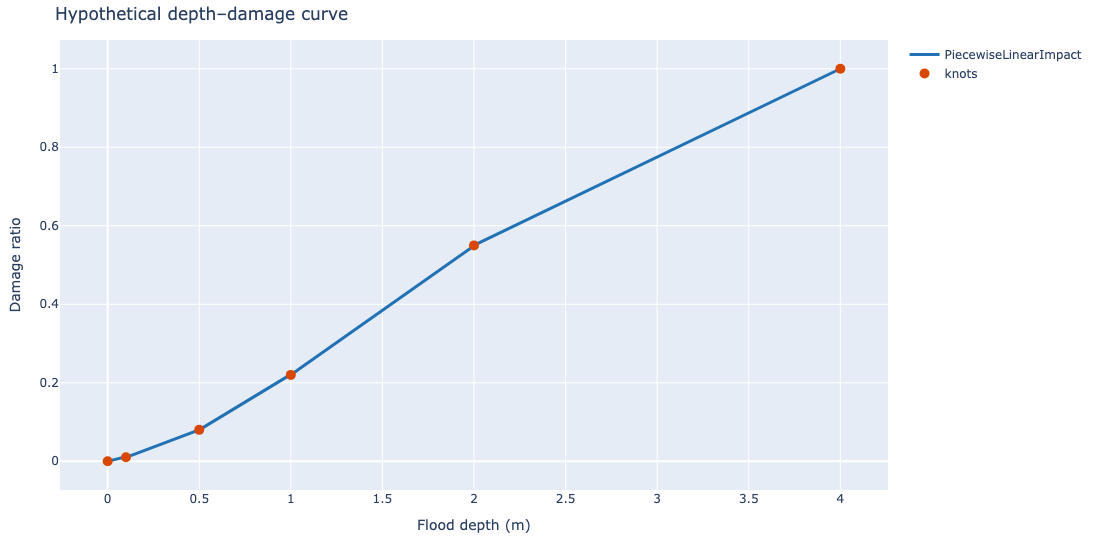

In [5]:
# Depth–damage curve itself
curve_x = np.linspace(0, 4, 200)
curve_y = np.asarray(DEPTH_DAMAGE.evaluate(curve_x), dtype=float)
fig_curve = go.Figure(
    go.Scatter(
        x=curve_x,
        y=curve_y,
        mode="lines",
        line=dict(color="#2171B5", width=3),
        name="PiecewiseLinearImpact",
    )
)
fig_curve.add_trace(
    go.Scatter(
        x=DEPTH_DAMAGE.exposure,
        y=DEPTH_DAMAGE.impact,
        mode="markers",
        marker=dict(size=10, color="#D94801"),
        name="knots",
    )
)
fig_curve.update_layout(
    title="Hypothetical depth–damage curve",
    xaxis_title="Flood depth (m)",
    yaxis_title="Damage ratio",
    margin=dict(l=60, r=40, t=40, b=60),
)
fig_curve.show()


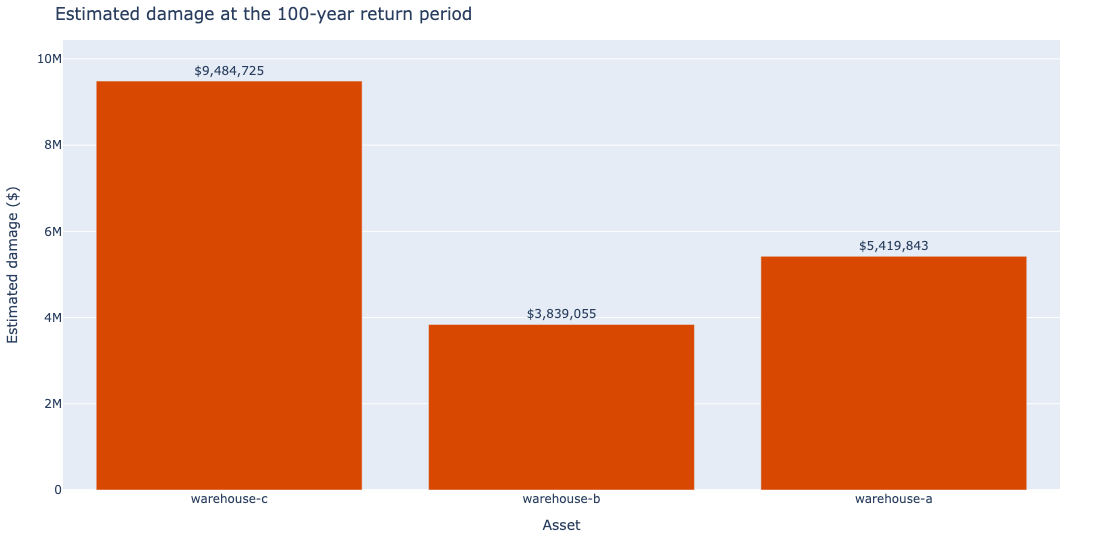

In [6]:
design = comparison[comparison["return_period"] == 100]
fig_damage = go.Figure(
    go.Bar(
        x=design["asset_id"],
        y=design["estimated_damage"],
        marker_color="#D94801",
        text=[f"${v:,.0f}" for v in design["estimated_damage"]],
        textposition="outside",
        customdata=np.stack(
            [design["depth_m"], design["damage_ratio"], design["replacement_value"]],
            axis=-1,
        ),
        hovertemplate=(
            "%{x}<br>damage=$%{y:,.0f}"
            "<br>depth=%{customdata[0]:.3f} m"
            "<br>ratio=%{customdata[1]:.3f}"
            "<br>replacement=$%{customdata[2]:,.0f}<extra></extra>"
        ),
    )
)
fig_damage.update_layout(
    title="Estimated damage at the 100-year return period",
    xaxis_title="Asset",
    yaxis_title="Estimated damage ($)",
    margin=dict(l=60, r=40, t=40, b=60),
)
fig_damage.show()


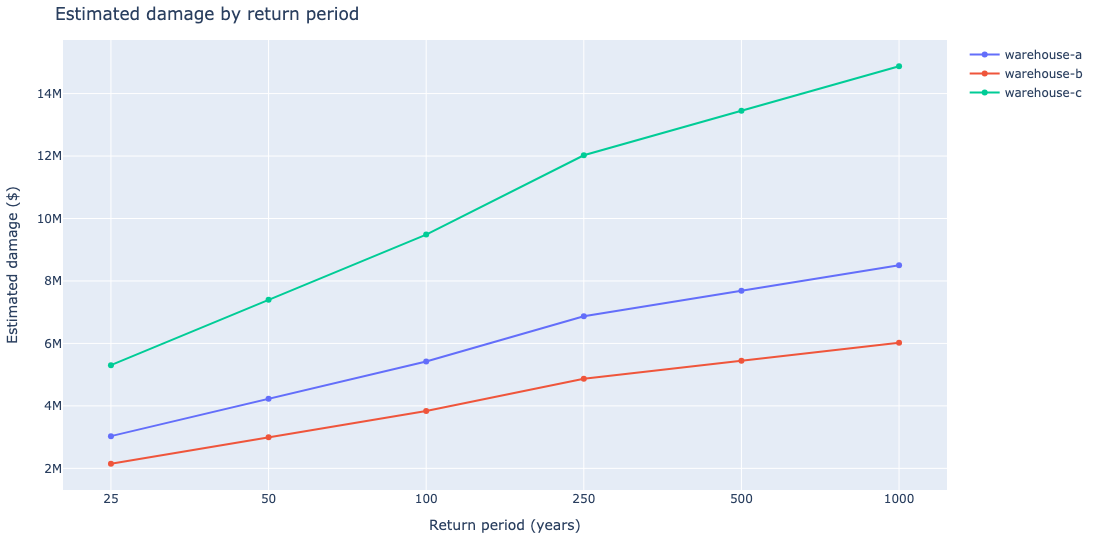

In [7]:
fig_escalation = go.Figure()
for asset_id, frame in comparison.groupby("asset_id"):
    frame = frame.sort_values("return_period")
    fig_escalation.add_trace(
        go.Scatter(
            x=[str(rp) for rp in frame["return_period"]],
            y=frame["estimated_damage"],
            mode="lines+markers",
            name=asset_id,
        )
    )
fig_escalation.update_layout(
    title="Estimated damage by return period",
    xaxis_title="Return period (years)",
    yaxis_title="Estimated damage ($)",
    margin=dict(l=60, r=40, t=40, b=60),
)
fig_escalation.show()


## Scaling this up

[`pipelines/portfolio_impact_pipeline.py`](https://github.com/RiskThinking/crc-docs/blob/main/pipelines/portfolio_impact_pipeline.py)
is the headless twin. It uses the same `PiecewiseLinearImpact` instance (picklable,
so `--max-workers` can rise above 1) and prints a depth / ratio / dollar table.
